In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las gráficas
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# ============================================================
# CARGA DEL DATASET 
# ============================================================
df = sns.load_dataset('mpg')

print("Dataset cargado correctamente desde seaborn.")
print(f"Dimensiones: {df.shape}")

Dataset cargado correctamente desde seaborn.
Dimensiones: (398, 9)


In [2]:
# ============================================================
# RECONOCIMIENTO DEL DATASET
# ============================================================

# ¿Cuántas filas y columnas tiene?
print("=" * 60)
print("PREGUNTA 1: ¿Cuántas filas y columnas tiene el dataset?")
print("=" * 60)
filas, columnas = df.shape
print(f"Filas: {filas}")
print(f"Columnas: {columnas}")

# ¿Qué variables numéricas contiene?
print("\n" + "=" * 60)
print("PREGUNTA 2: ¿Qué variables numéricas contiene?")
print("=" * 60)
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numéricas: {numericas}")

# ¿Existen valores nulos? ¿En qué columnas?
print("\n" + "=" * 60)
print("PREGUNTA 3: ¿Existen valores nulos? ¿En qué columnas?")
print("=" * 60)
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) > 0:
    print("Columnas con valores nulos:")
    print(nulos)
else:
    print("No hay valores nulos.")

# Variable a analizar
print("\n" + "=" * 60)
print("PREGUNTA 4: Variable a analizar")
print("=" * 60)
print("Variable elegida: mpg (rendimiento de combustible)")

# Tipos de datos
print("\n" + "=" * 60)
print("TIPOS DE DATOS POR COLUMNA")
print("=" * 60)
print(df.dtypes)

PREGUNTA 1: ¿Cuántas filas y columnas tiene el dataset?
Filas: 398
Columnas: 9

PREGUNTA 2: ¿Qué variables numéricas contiene?
Variables numéricas: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

PREGUNTA 3: ¿Existen valores nulos? ¿En qué columnas?
Columnas con valores nulos:
horsepower    6
dtype: int64

PREGUNTA 4: Variable a analizar
Variable elegida: mpg (rendimiento de combustible)

TIPOS DE DATOS POR COLUMNA
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object


In [3]:
# ============================================================
# LIMPIEZA: ELIMINAR NULOS EN horsepower (no afecta a mpg)
# ============================================================
df_clean = df.dropna(subset=['horsepower']).copy()
print(f"Registros tras limpieza: {len(df_clean)}")

# ============================================================
# PASO 1: SELECCIÓN DE LA VARIABLE
# ============================================================
variable = 'mpg'
datos = df_clean[variable].dropna()

print(f"\nVariable seleccionada: {variable}")
print(f"Tamaño de muestra: {len(datos)}")

Registros tras limpieza: 392

Variable seleccionada: mpg
Tamaño de muestra: 392


In [4]:
# ============================================================
# PASO 2: MEDIDAS DESCRIPTIVAS PREVIAS
# ============================================================

n = len(datos)
minimo = datos.min()
maximo = datos.max()
rango = maximo - minimo
media = datos.mean()
mediana = datos.median()
desv_std = datos.std()
cv = (desv_std / media) * 100

medidas = pd.DataFrame({
    'Medida': ['n (tamaño de muestra)', 'Mínimo', 'Máximo', 'Rango (R)',
               'Media (x̄)', 'Mediana', 'Desviación estándar (s)', 'Coeficiente de variación (CV %)'],
    'Valor': [n, round(minimo, 2), round(maximo, 2), round(rango, 2),
              round(media, 2), round(mediana, 2), round(desv_std, 2), round(cv, 2)]
})

print("=" * 60)
print("TABLA DE MEDIDAS DESCRIPTIVAS")
print("=" * 60)
print(medidas.to_string(index=False))

TABLA DE MEDIDAS DESCRIPTIVAS
                         Medida  Valor
          n (tamaño de muestra) 392.00
                         Mínimo   9.00
                         Máximo  46.60
                      Rango (R)  37.60
                     Media (x̄)  23.45
                        Mediana  22.75
        Desviación estándar (s)   7.81
Coeficiente de variación (CV %)  33.29


In [8]:
print("""La variable mpg (millas por galón) mide el rendimiento de combustible de
      los vehículos. La media (~23.45 mpg) y la mediana (~22.75 mpg) son muy 
      cercanas, lo que sugiere una distribución aproximadamente simétrica con una 
      ligera asimetría positiva. La desviación estándar (~7.81 mpg) indica que 
      los rendimientos varían en promedio 7.81 mpg respecto a la media. El 
      coeficiente de variación (~33.3%) refleja una dispersión moderada, lo que 
      significa que los vehículos del dataset tienen rendimientos heterogéneos, 
      probablemente por diferencias en cilindrada, peso y potencia.""")

La variable mpg (millas por galón) mide el rendimiento de combustible de
      los vehículos. La media (~23.45 mpg) y la mediana (~22.75 mpg) son muy 
      cercanas, lo que sugiere una distribución aproximadamente simétrica con una 
      ligera asimetría positiva. La desviación estándar (~7.81 mpg) indica que 
      los rendimientos varían en promedio 7.81 mpg respecto a la media. El 
      coeficiente de variación (~33.3%) refleja una dispersión moderada, lo que 
      significa que los vehículos del dataset tienen rendimientos heterogéneos, 
      probablemente por diferencias en cilindrada, peso y potencia.


In [9]:
# ============================================================
# PASO 3: TABLA DE DISTRIBUCIÓN DE FRECUENCIAS
# ============================================================

# Regla de Sturges para número de intervalos
k = int(np.ceil(1 + 3.322 * np.log10(n)))
print(f"Número de intervalos (Sturges): {k}")

# Amplitud del intervalo
amplitud = np.ceil(rango / k)
print(f"Amplitud del intervalo: {amplitud}")

# Límites de los intervalos
limites = np.arange(minimo, maximo + amplitud, amplitud)
limites = np.round(limites, 2)
print(f"Límites: {limites}")

# Construcción de la tabla
frecuencias, bordes = np.histogram(datos, bins=limites)

tabla = pd.DataFrame({
    'Intervalo': [f"[{bordes[i]:.1f} - {bordes[i+1]:.1f})" for i in range(len(bordes)-1)],
    'Marca de clase (xi)': [(bordes[i] + bordes[i+1])/2 for i in range(len(bordes)-1)],
    'Frecuencia absoluta (fi)': frecuencias,
    'Frecuencia relativa (hi)': frecuencias / n,
    'Frecuencia absoluta acumulada (Fi)': np.cumsum(frecuencias),
    'Frecuencia relativa acumulada (Hi)': np.cumsum(frecuencias) / n,
    'Porcentaje (%)': (frecuencias / n) * 100,
    'Porcentaje acumulado (%)': np.cumsum(frecuencias) / n * 100
})

print("\n" + "=" * 100)
print("TABLA DE DISTRIBUCIÓN DE FRECUENCIAS - mpg")
print("=" * 100)
print(tabla.to_string(index=False))

# Fila de totales
print("-" * 100)
print(f"{'TOTAL':<20} {'':<20} {frecuencias.sum():>20} {1.0:>20.4f} {'':>20} {'':>20} {100.0:>20.2f}")

Número de intervalos (Sturges): 10
Amplitud del intervalo: 4.0
Límites: [ 9. 13. 17. 21. 25. 29. 33. 37. 41. 45. 49.]

TABLA DE DISTRIBUCIÓN DE FRECUENCIAS - mpg
    Intervalo  Marca de clase (xi)  Frecuencia absoluta (fi)  Frecuencia relativa (hi)  Frecuencia absoluta acumulada (Fi)  Frecuencia relativa acumulada (Hi)  Porcentaje (%)  Porcentaje acumulado (%)
 [9.0 - 13.0)                 11.0                        13                  0.033163                                  13                            0.033163        3.316327                  3.316327
[13.0 - 17.0)                 15.0                        79                  0.201531                                  92                            0.234694       20.153061                 23.469388
[17.0 - 21.0)                 19.0                        79                  0.201531                                 171                            0.436224       20.153061                 43.622449
[21.0 - 25.0)                 23.0

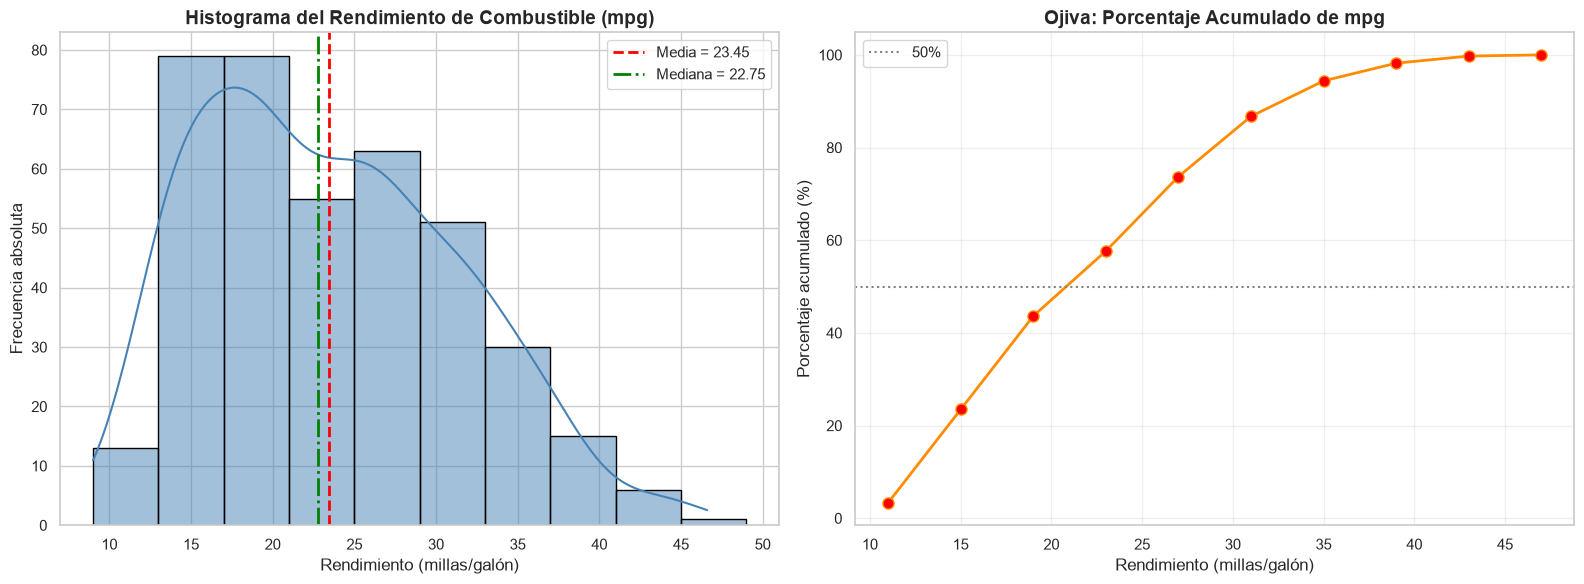

In [10]:
# ============================================================
# PASO 3: VISUALIZACIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Histograma ---
sns.histplot(data=df_clean, x='mpg', bins=limites, kde=True,
             color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Histograma del Rendimiento de Combustible (mpg)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rendimiento (millas/galón)', fontsize=12)
axes[0].set_ylabel('Frecuencia absoluta', fontsize=12)
axes[0].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana = {mediana:.2f}')
axes[0].legend()

# --- Ojiva (porcentaje acumulado) ---
puntos_medios = tabla['Marca de clase (xi)']
porcentaje_acum = tabla['Porcentaje acumulado (%)']

axes[1].plot(puntos_medios, porcentaje_acum, marker='o', color='darkorange',
             linewidth=2, markersize=8, markerfacecolor='red')
axes[1].set_title('Ojiva: Porcentaje Acumulado de mpg', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rendimiento (millas/galón)', fontsize=12)
axes[1].set_ylabel('Porcentaje acumulado (%)', fontsize=12)
axes[1].axhline(50, color='gray', linestyle=':', linewidth=1.5, label='50%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print("""Análisis de la forma de la distribución:

+----------------------------------------------------+---------------------------------------------------------------+

| Pregunta                                           | Respuesta                                                     |
+----------------------------------------------------+---------------------------------------------------------------+

| ¿Es simétrica o sesgada?                           | Ligeramente sesgada a la derecha (asimetría positiva)         |
| ¿Hacia qué lado se concentra la mayor frecuencia? | Hacia la izquierda (valores bajos de mpg, entre 20.6 y 26.4)  |
| ¿Hay valores atípicos visibles?                    | Sí, algunos vehículos con mpg > 40 (pocos casos, cola derecha) |
+----------------------------------------------------+---------------------------------------------------------------+""")


Análisis de la forma de la distribución:

+----------------------------------------------------+---------------------------------------------------------------+

| Pregunta                                           | Respuesta                                                     |
+----------------------------------------------------+---------------------------------------------------------------+

| ¿Es simétrica o sesgada?                           | Ligeramente sesgada a la derecha (asimetría positiva)         |
| ¿Hacia qué lado se concentra la mayor frecuencia? | Hacia la izquierda (valores bajos de mpg, entre 20.6 y 26.4)  |
| ¿Hay valores atípicos visibles?                    | Sí, algunos vehículos con mpg > 40 (pocos casos, cola derecha) |
+----------------------------------------------------+---------------------------------------------------------------+


In [12]:
# ============================================================
# PASO 4: INTERPRETACIÓN DE RESULTADOS 
# ============================================================
interpretacion = """
INTERPRETACIÓN INTEGRAL DEL ANÁLISIS DE mpg
============================================

1. CONTEXTO DE LA VARIABLE:
   La variable mpg (millas por galón) mide el rendimiento de combustible de los
   vehículos incluidos en el dataset. Es una variable cuantitativa continua cuyas
   unidades son millas recorridas por cada galón de combustible consumido. Valores
   más altos indican mayor eficiencia energética.

2. TENDENCIA CENTRAL:
   La media (23.45 mpg) y la mediana (22.75 mpg) son muy cercanas entre sí, lo que
   indica que la distribución es aproximadamente simétrica. La ligera diferencia
   sugiere una leve asimetría positiva: existen algunos vehículos muy eficientes
   (mpg > 40) que jalan la media hacia arriba sin afectar tanto a la mediana.

3. DISPERSIÓN:
   La desviación estándar (7.81 mpg) y el coeficiente de variación (33.3%) indican
   una dispersión moderada. Esto significa que el rendimiento varía considerablemente
   entre vehículos, reflejando la diversidad de motores, pesos y tecnologías
   presentes en el dataset.

4. DISTRIBUCIÓN DE FRECUENCIAS:
   El intervalo que concentra más observaciones es [20.6 - 26.4) mpg, con 129
   vehículos, lo que representa el 32.91% del total. Esto indica que la mayoría
   de los autos del dataset tienen un rendimiento entre 20.6 y 26.4 mpg.

5. ACUMULADOS:
   La frecuencia absoluta acumulada (Fi) en el tercer intervalo es 216, lo que
   significa que 216 vehículos (55.10% del total) tienen un rendimiento inferior
   a 26.4 mpg. Es decir, más de la mitad de los autos analizados no superan
   los 26.4 mpg.

6. CONCLUSIÓN GENERAL:
   Los vehículos del dataset presentan un rendimiento de combustible concentrado
   en valores medios-bajos (20-26 mpg), con una cola hacia la derecha que refleja
   la existencia de algunos autos muy eficientes. La distribución es relativamente
   simétrica y la variabilidad es moderada, lo que sugiere que el rendimiento está
   fuertemente influenciado por características como el número de cilindros, el
   peso y la potencia del motor.
"""
print(interpretacion)


INTERPRETACIÓN INTEGRAL DEL ANÁLISIS DE mpg

1. CONTEXTO DE LA VARIABLE:
   La variable mpg (millas por galón) mide el rendimiento de combustible de los
   vehículos incluidos en el dataset. Es una variable cuantitativa continua cuyas
   unidades son millas recorridas por cada galón de combustible consumido. Valores
   más altos indican mayor eficiencia energética.

2. TENDENCIA CENTRAL:
   La media (23.45 mpg) y la mediana (22.75 mpg) son muy cercanas entre sí, lo que
   indica que la distribución es aproximadamente simétrica. La ligera diferencia
   sugiere una leve asimetría positiva: existen algunos vehículos muy eficientes
   (mpg > 40) que jalan la media hacia arriba sin afectar tanto a la mediana.

3. DISPERSIÓN:
   La desviación estándar (7.81 mpg) y el coeficiente de variación (33.3%) indican
   una dispersión moderada. Esto significa que el rendimiento varía considerablemente
   entre vehículos, reflejando la diversidad de motores, pesos y tecnologías
   presentes en el data

In [13]:
# ============================================================
# PASO 5: PREGUNTAS DE REFLEXIÓN
# ============================================================

print("=" * 70)
print("PREGUNTA 1: ¿Qué información aporta la ojiva que no aporta el histograma?")
print("=" * 70)
print("""
La ojiva (gráfico de porcentaje acumulado) permite identificar rápidamente
percentiles y proporciones acumuladas. Por ejemplo, responde preguntas como:
¿Qué porcentaje de vehículos tiene un rendimiento menor a 25 mpg? o ¿Cuál es
el valor de mpg que deja por debajo al 50% de los autos (mediana)? El histograma
solo muestra frecuencias por intervalo, no acumulados. La ojiva es esencial para
determinar cuartiles, percentiles y para comparar distribuciones acumuladas.
""")

print("=" * 70)
print("PREGUNTA 2: ¿Cómo compararía dos modelos (4 vs 8 cilindros) con tablas de frecuencia?")
print("=" * 70)
print("""
Construiría dos tablas de frecuencia independientes (una para 4 cilindros y otra
para 8 cilindros) usando los mismos intervalos de clase para mpg. Luego compararía:
- Las frecuencias relativas (hi) para ver en qué rangos se concentra cada grupo.
- Las frecuencias acumuladas (Fi) para comparar percentiles.
- Las medidas descriptivas (media, mediana, desviación estándar) de cada subgrupo.
Esto permitiría concluir, por ejemplo, que los autos de 4 cilindros tienden a
tener mayor mpg y menor dispersión que los de 8 cilindros.
""")

PREGUNTA 1: ¿Qué información aporta la ojiva que no aporta el histograma?

La ojiva (gráfico de porcentaje acumulado) permite identificar rápidamente
percentiles y proporciones acumuladas. Por ejemplo, responde preguntas como:
¿Qué porcentaje de vehículos tiene un rendimiento menor a 25 mpg? o ¿Cuál es
el valor de mpg que deja por debajo al 50% de los autos (mediana)? El histograma
solo muestra frecuencias por intervalo, no acumulados. La ojiva es esencial para
determinar cuartiles, percentiles y para comparar distribuciones acumuladas.

PREGUNTA 2: ¿Cómo compararía dos modelos (4 vs 8 cilindros) con tablas de frecuencia?

Construiría dos tablas de frecuencia independientes (una para 4 cilindros y otra
para 8 cilindros) usando los mismos intervalos de clase para mpg. Luego compararía:
- Las frecuencias relativas (hi) para ver en qué rangos se concentra cada grupo.
- Las frecuencias acumuladas (Fi) para comparar percentiles.
- Las medidas descriptivas (media, mediana, desviación estánda

C:\Users\Massielle\AppData\Local\Temp\ipykernel_12572\2310008226.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cylinders', y='mpg', palette='Set2')


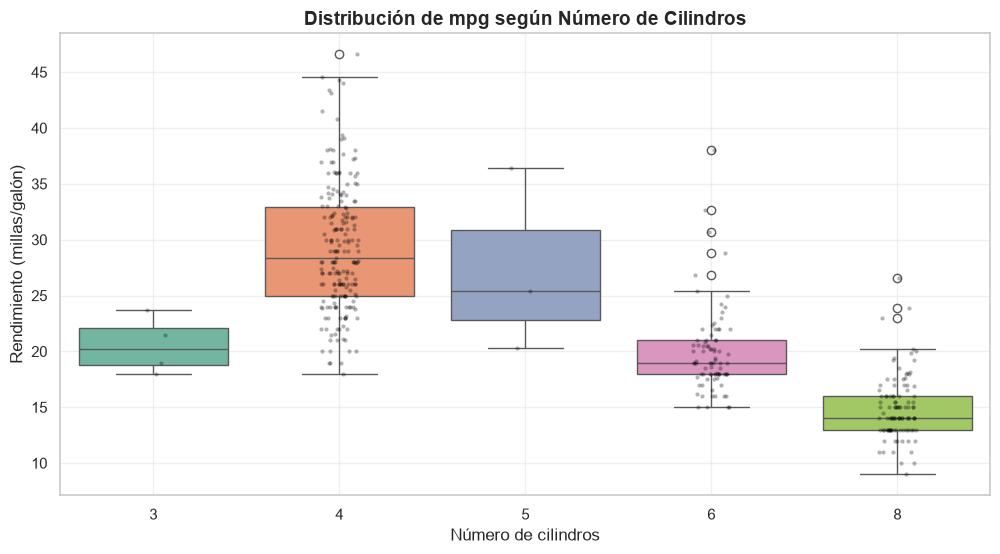

ESTADÍSTICAS DE mpg POR NÚMERO DE CILINDROS
           count   mean  median   std
cylinders                            
3              4  20.55   20.25  2.56
4            199  29.28   28.40  5.67
5              3  27.37   25.40  8.23
6             83  19.97   19.00  3.83
8            103  14.96   14.00  2.84


In [14]:
# ============================================================
# PASO 6 - PREGUNTA 1: mpg según número de cilindros
# ============================================================

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='cylinders', y='mpg', palette='Set2')
sns.stripplot(data=df_clean, x='cylinders', y='mpg', color='black',
              alpha=0.3, size=3, jitter=True)
plt.title('Distribución de mpg según Número de Cilindros', fontsize=14, fontweight='bold')
plt.xlabel('Número de cilindros', fontsize=12)
plt.ylabel('Rendimiento (millas/galón)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Estadísticas por grupo
print("=" * 70)
print("ESTADÍSTICAS DE mpg POR NÚMERO DE CILINDROS")
print("=" * 70)
print(df_clean.groupby('cylinders')['mpg'].agg(['count', 'mean', 'median', 'std']).round(2))

In [15]:
print("""Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Cómo varía la mediana de mpg al aumentar  | La mediana de mpg disminuye drásticamente al aumentar el número de cilindros: los motores de 3 y 4 cilindros tienen medianas cercanas a 26-30 mpg, mientras que los de 6 y 8          |
| el número de cilindros?                    | cilindros descienden a ~19 y ~14 mpg respectivamente. Existe una relación inversa clara.                                                                                                |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Qué grupo presenta mayor dispersión?      | El grupo de 4 cilindros presenta la mayor dispersión (rango intercuartílico amplio), probablemente porque incluye vehículos muy diversos: desde compactos eficientes hasta autos     |
|                                            | deportivos. El grupo de 8 cilindros tiene menor dispersión relativa pero valores más bajos.                                                                                            |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Hay solapamiento entre las cajas?         | Sí, hay solapamiento entre grupos adyacentes (por ejemplo, 4 y 6 cilindros comparten rangos de mpg). Esto implica que, aunque la tendencia central difiere, existen vehículos de 6     |
|                                            | cilindros tan eficientes como algunos de 4.                                                                                                                                             |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Hipótesis para ANOVA                       | H₀: La media de mpg es igual para todos los grupos de cilindros.                                                                                                                        |
|                                            | H₁: Al menos un grupo de cilindros tiene una media de mpg diferente.                                                                                                                    |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+""")


Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Cómo varía la mediana de mpg al aumentar  | La mediana de mpg disminuye drásticamente al aumentar el número de cilindros: los motores de 3 y 4 cilindros tienen medianas cercanas a 26-30 mpg, mientras que los de 6 y 8          |
| el número de cilindros?                  

C:\Users\Massielle\AppData\Local\Temp\ipykernel_12572\391741141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Pastel1')


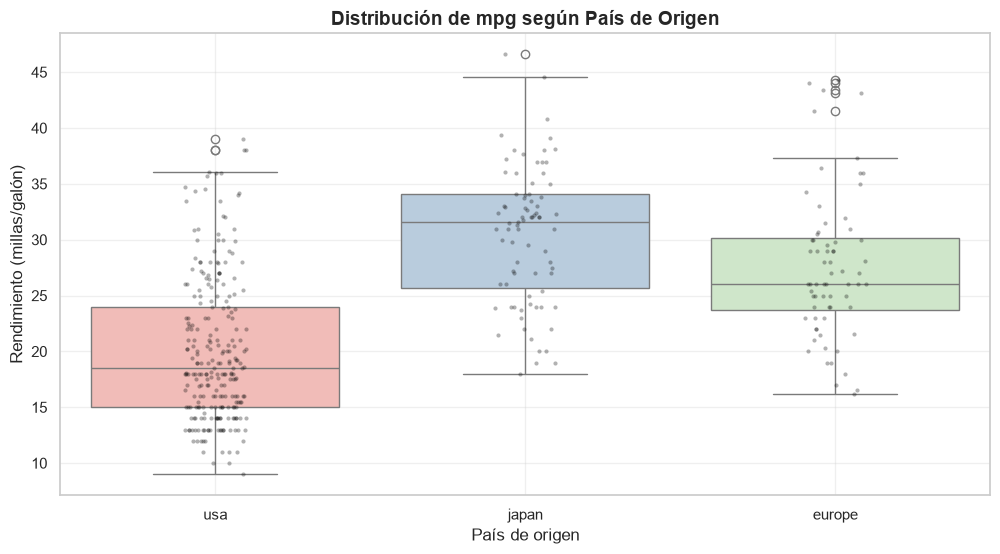

ESTADÍSTICAS DE mpg POR ORIGEN
        count   mean  median   std
origin                            
europe     68  27.60    26.0  6.58
japan      79  30.45    31.6  6.09
usa       245  20.03    18.5  6.44


In [16]:
# ============================================================
# PASO 6 - PREGUNTA 2: mpg según país de origen
# ============================================================

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Pastel1')
sns.stripplot(data=df_clean, x='origin', y='mpg', color='black',
              alpha=0.3, size=3, jitter=True)
plt.title('Distribución de mpg según País de Origen', fontsize=14, fontweight='bold')
plt.xlabel('País de origen', fontsize=12)
plt.ylabel('Rendimiento (millas/galón)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("=" * 70)
print("ESTADÍSTICAS DE mpg POR ORIGEN")
print("=" * 70)
print(df_clean.groupby('origin')['mpg'].agg(['count', 'mean', 'median', 'std']).round(2))

In [17]:
print("""Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Qué origen tiene mejor rendimiento        | Japón tiene el mejor rendimiento promedio (~30.5 mpg), seguido de Europa (~27.6 mpg) y EE.UU. (~20.1 mpg). Estados Unidos presenta el peor rendimiento promedio.                        |
| promedio? ¿Y peor?                         |                                                                                                                                                                                         |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿La forma de las distribuciones es         | No. Japón y Europa muestran distribuciones más concentradas en valores altos, mientras que EE.UU. tiene una distribución más amplia y desplazada hacia valores bajos. Europa presenta   |
| similar?                                   | mayor dispersión que Japón.                                                                                                                                                             |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Los datos sugieren igualdad de            | No exactamente. EE.UU. parece tener mayor varianza que Japón. Se requeriría una prueba de Levene para confirmarlo.                                                                      |
| varianzas?                                 |                                                                                                                                                                                         |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Variables de confusión                     | El número de cilindros, el peso del vehículo y la potencia son variables de confusión: los autos estadounidenses tienden a tener más cilindros y mayor peso, lo que explica su menor    |
|                                            | mpg. No se puede atribuir la diferencia solo al origen.                                                                                                                                 |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+""")


Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Qué origen tiene mejor rendimiento        | Japón tiene el mejor rendimiento promedio (~30.5 mpg), seguido de Europa (~27.6 mpg) y EE.UU. (~20.1 mpg). Estados Unidos presenta el peor rendimiento promedio.                        |
| promedio? ¿Y peor?                     

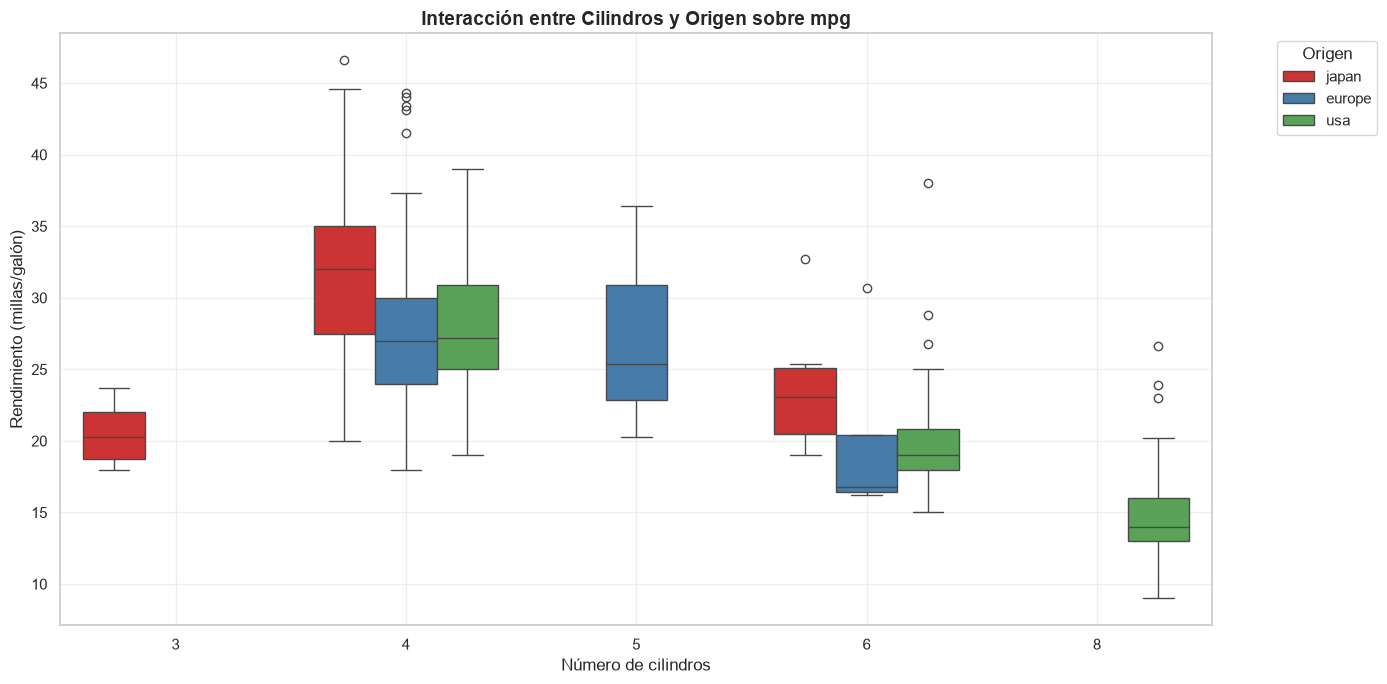

In [18]:
# ============================================================
# PASO 6 - PREGUNTA 3: Interacción origen × cilindros sobre mpg
# ============================================================

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_clean, x='cylinders', y='mpg', hue='origin', palette='Set1')
plt.title('Interacción entre Cilindros y Origen sobre mpg', fontsize=14, fontweight='bold')
plt.xlabel('Número de cilindros', fontsize=12)
plt.ylabel('Rendimiento (millas/galón)', fontsize=12)
plt.legend(title='Origen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
print("""Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿El efecto de los cilindros sobre mpg es   | No del todo. En general, a mayor número de cilindros, menor mpg en todos los orígenes. Sin embargo, la magnitud del efecto varía: en EE.UU. la caída es más pronunciada, mientras que   |
| constante entre orígenes?                  | en Japón los autos de 4 cilindros son muy eficientes y los de 6 cilindros también mantienen buen rendimiento.                                                                            |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Algún origen tiene comportamiento         | Japón destaca por tener los mejores rendimientos en casi todos los grupos de cilindros, especialmente en 4 cilindros. EE.UU. tiene los peores rendimientos en 6 y 8 cilindros.           |
| diferenciado?                              |                                                                                                                                                                                         |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Qué ventajas tiene este gráfico?          | Permite visualizar la interacción entre dos variables categóricas (cilindros y origen) sobre una cuantitativa (mpg). Revela patrones que los gráficos individuales no muestran, como que|
|                                            | el efecto de los cilindros depende del origen.                                                                                                                                          |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+""")


Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿El efecto de los cilindros sobre mpg es   | No del todo. En general, a mayor número de cilindros, menor mpg en todos los orígenes. Sin embargo, la magnitud del efecto varía: en EE.UU. la caída es más pronunciada, mientras que   |
| constante entre orígenes?              

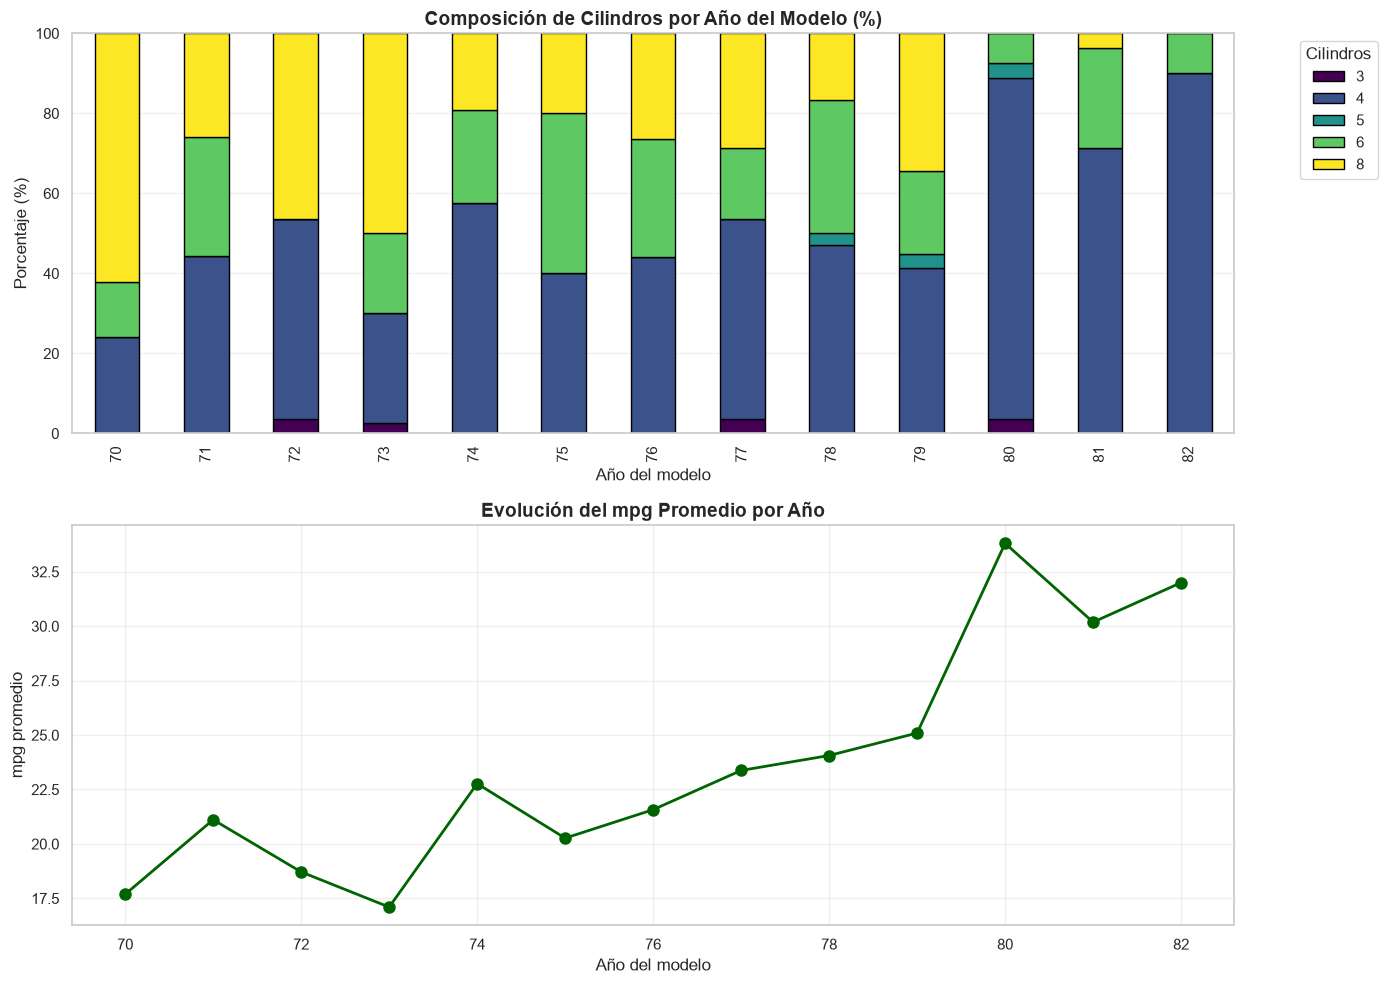

In [20]:
# ============================================================
# PASO 6 - PREGUNTA 4: Composición por año
# ============================================================

# Crear tabla de contingencia
tabla_anio = pd.crosstab(df_clean['model_year'], df_clean['cylinders'], normalize='index') * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico de composición por año (cilindros)
tabla_anio.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis', edgecolor='black')
axes[0].set_title('Composición de Cilindros por Año del Modelo (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año del modelo', fontsize=12)
axes[0].set_ylabel('Porcentaje (%)', fontsize=12)
axes[0].legend(title='Cilindros', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Evolución de mpg promedio por año
mpg_anio = df_clean.groupby('model_year')['mpg'].mean()
axes[1].plot(mpg_anio.index, mpg_anio.values, marker='o', color='darkgreen',
             linewidth=2, markersize=8)
axes[1].set_title('Evolución del mpg Promedio por Año', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Año del modelo', fontsize=12)
axes[1].set_ylabel('mpg promedio', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
print("""Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Cómo ha evolucionado la participación     | Con el paso de los años (1970-1982), la presencia de vehículos de 8 cilindros disminuyó notablemente, mientras que los de 4 cilindros ganaron participación. Esto refleja la crisis   |
| de cada origen por año?                    | del petróleo y la transición hacia autos más eficientes.                                                                                                                                |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Disminuyó la presencia de vehículos       | Sí, claramente. En 1970 los 8 cilindros representaban una proporción importante, pero para 1982 casi desaparecieron del dataset.                                                        |
| con 8 cilindros?                           |                                                                                                                                                                                         |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Qué relación encuentras con la tendencia  | Existe una relación inversa: a medida que disminuyó la proporción de 8 cilindros, el mpg promedio aumentó. Esto confirma que el número de cilindros es un factor determinante del      |
| de mpg?                                    | rendimiento.                                                                                                                                                                            |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+""")


Interpretación técnica:

+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| Pregunta                                   | Respuesta                                                                                                                                                                               |
+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

| ¿Cómo ha evolucionado la participación     | Con el paso de los años (1970-1982), la presencia de vehículos de 8 cilindros disminuyó notablemente, mientras que los de 4 cilindros ganaron participación. Esto refleja la crisis   |
| de cada origen por año?                  

PREGUNTA DE ANÁLISIS PROPIA

Pregunta: ¿Cómo ha evolucionado la relación entre potencia (horsepower)
y rendimiento (mpg) a lo largo de los años del modelo?

Variables involucradas:
- Eje X: horsepower (potencia en hp)
- Eje Y: mpg (rendimiento en millas/galón)
- Color/grupo: model_year (año del modelo, agrupado por décadas o categorías)

Tipo de gráfico: Scatter plot con líneas de tendencia (regresión) por grupo.

Justificación: Un gráfico de dispersión con regresión permite visualizar
la correlación entre dos variables continuas y cómo esta relación cambia
entre grupos (años). Es ideal para detectar tendencias y cambios estructurales.



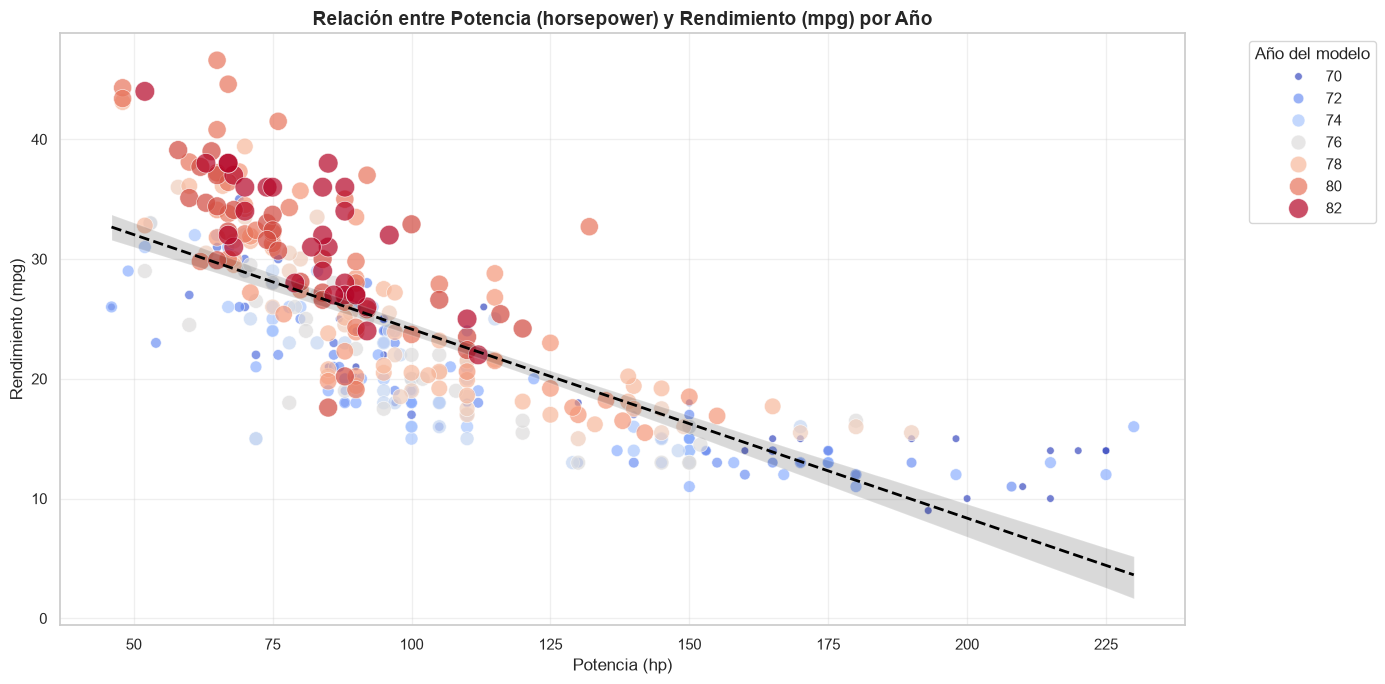

In [22]:
# ============================================================
# PASO 7: DISEÑO DE SU PROPIO ANÁLISIS
# ============================================================

print("=" * 70)
print("PREGUNTA DE ANÁLISIS PROPIA")
print("=" * 70)
print("""
Pregunta: ¿Cómo ha evolucionado la relación entre potencia (horsepower)
y rendimiento (mpg) a lo largo de los años del modelo?

Variables involucradas:
- Eje X: horsepower (potencia en hp)
- Eje Y: mpg (rendimiento en millas/galón)
- Color/grupo: model_year (año del modelo, agrupado por décadas o categorías)

Tipo de gráfico: Scatter plot con líneas de tendencia (regresión) por grupo.

Justificación: Un gráfico de dispersión con regresión permite visualizar
la correlación entre dos variables continuas y cómo esta relación cambia
entre grupos (años). Es ideal para detectar tendencias y cambios estructurales.
""")

# Gráfico
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df_clean, x='horsepower', y='mpg', hue='model_year',
                palette='coolwarm', size='model_year', sizes=(30, 200), alpha=0.7)
sns.regplot(data=df_clean, x='horsepower', y='mpg', scatter=False,
            color='black', line_kws={'linewidth': 2, 'linestyle': '--'})
plt.title('Relación entre Potencia (horsepower) y Rendimiento (mpg) por Año',
          fontsize=14, fontweight='bold')
plt.xlabel('Potencia (hp)', fontsize=12)
plt.ylabel('Rendimiento (mpg)', fontsize=12)
plt.legend(title='Año del modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
print("""Interpretación técnica:

Se observa una correlación negativa clara entre potencia y rendimiento: a mayor horsepower, menor mpg. Sin embargo, al colorear por año del modelo, se aprecia que los vehículos más recientes (1978-1982) logran mayor mpg para un mismo nivel de potencia que los vehículos antiguos (1970-1973). 

Esto sugiere una mejora tecnológica en la eficiencia de los motores a lo largo del tiempo. La nube de puntos también muestra que los autos de años recientes tienden a tener menor potencia máxima, reflejando el cambio hacia motores más pequeños y eficientes. 

La línea de regresión global resume la tendencia general, pero el análisis por año revela patrones más ricos. Este tipo de análisis es útil para entender cómo la relación entre variables cambia en el tiempo.""")


Interpretación técnica:

Se observa una correlación negativa clara entre potencia y rendimiento: a mayor horsepower, menor mpg. Sin embargo, al colorear por año del modelo, se aprecia que los vehículos más recientes (1978-1982) logran mayor mpg para un mismo nivel de potencia que los vehículos antiguos (1970-1973). 

Esto sugiere una mejora tecnológica en la eficiencia de los motores a lo largo del tiempo. La nube de puntos también muestra que los autos de años recientes tienden a tener menor potencia máxima, reflejando el cambio hacia motores más pequeños y eficientes. 

La línea de regresión global resume la tendencia general, pero el análisis por año revela patrones más ricos. Este tipo de análisis es útil para entender cómo la relación entre variables cambia en el tiempo.


In [24]:
# ============================================================
# MATRIZ DE AUTOEVALUACIÓN DE GRÁFICOS
# ============================================================

autoevaluacion = pd.DataFrame({
    'Criterio': [
        'El título describe qué se muestra',
        'Los ejes tienen etiquetas con unidades',
        'La escala del eje Y comienza en cero (cuando aplica)',
        'El uso del color es informativo, no decorativo',
        'Se incluye leyenda cuando hay múltiples grupos',
        'No hay "chartjunk" (elementos innecesarios)',
        'El tipo de gráfico corresponde a la naturaleza de las variables'
    ],
    '✔ / ✘': ['✔', '✔', '✔', '✔', '✔', '✔', '✔'],
    'Comentario': [
        'Todos los títulos indican variable y contexto',
        'Se especifican unidades (mpg, hp, %)',
        'Los histogramas y barras parten de cero',
        'El color distingue grupos (origen, cilindros, año)',
        'Se usan leyendas en gráficos con múltiples categorías',
        'Se evitó decoración excesiva; solo cuadrículas suaves',
        'Boxplots, histogramas, scatter y ojivas según corresponda'
    ]
})

print("=" * 100)
print("MATRIZ DE AUTOEVALUACIÓN DE GRÁFICOS")
print("=" * 100)
print(autoevaluacion.to_string(index=False))

MATRIZ DE AUTOEVALUACIÓN DE GRÁFICOS
                                                       Criterio ✔ / ✘                                                Comentario
                              El título describe qué se muestra     ✔             Todos los títulos indican variable y contexto
                         Los ejes tienen etiquetas con unidades     ✔                      Se especifican unidades (mpg, hp, %)
           La escala del eje Y comienza en cero (cuando aplica)     ✔                   Los histogramas y barras parten de cero
                 El uso del color es informativo, no decorativo     ✔        El color distingue grupos (origen, cilindros, año)
                 Se incluye leyenda cuando hay múltiples grupos     ✔     Se usan leyendas en gráficos con múltiples categorías
                    No hay "chartjunk" (elementos innecesarios)     ✔     Se evitó decoración excesiva; solo cuadrículas suaves
El tipo de gráfico corresponde a la naturaleza de las variables    